# Bootstrap CIs and Identity Spot-Check

This notebook demonstrates the evaluation artifact for the founder-exit / repo-survival experiment.

Given `full_method_out.json` from the upstream experiment (62 curated GitHub repos, 47 passing prefilters, 30 forming the founder-only-TFDD analysis corpus: 11 survivors vs 19 non-survivors), it runs four analyses:

1. **Step 1** — nonparametric bootstrap 95% confidence intervals on Cohen's *d* for three snapshot covariates (`developers_at_tfdd`, `commits_at_tfdd`, `files_at_tfdd`) where raw per-repo arrays are reconstructable, compared against Avelino et al.'s (ESEM 2019) reference range.
2. **Step 2** — an attempt at a bootstrap CI on the placebo test's empirical percentile, which turns out to be **not reconstructable** from the persisted artifact — a concrete, explicitly documented gap.
3. **Step 3** — a deterministic 12-repo manual spot-check of the founder identity-resolution heuristic against live (unauthenticated) GitHub REST API data.
4. **Step 4** — a reclassification of the three pre-registered success criteria into `TESTED_NULL` / `TESTED_LOW_RESOLUTION` / `UNTESTABLE_AT_SCALE`.

The code below is a lightly reformatted, cell-split version of the original `eval.py` — same logic, same computations, just annotated and runnable end-to-end here.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# requests, loguru -- NOT pre-installed on Colab, always install
_pip('requests==2.32.4')
_pip('loguru==0.7.3')

# numpy, matplotlib -- pre-installed on Colab, install locally only to match Colab's exact version
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2')
    _pip('matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# -- imports (copy of the original eval.py import block, plus matplotlib for the results plot) --
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import numpy as np
import requests
from loguru import logger
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

GH_HEADERS = {
    "Accept": "application/vnd.github+json",
    "User-Agent": "aii-eval-identity-spotcheck",
}

## Load data

`mini_demo_data.json` mirrors the upstream experiment's `full_method_out.json` format exactly (same `metadata` + `datasets[0].examples` shape), so the rest of the code can stay unmodified. It's fetched from GitHub with a local-file fallback so the notebook works both standalone and after being pushed to the repo.

In [ ]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-24ffbe-pre-departure-bus-factor-diffusion/main/round-2/evaluation-1/demo/mini_demo_data.json"

import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
raw_data = load_data()
print(f"loaded keys: {list(raw_data.keys())}")
print(f"n examples: {len(raw_data['datasets'][0]['examples'])}")

loaded keys: ['metadata', 'datasets']
n examples: 62


## Config

All tunable parameters live here. `B_BOOTSTRAP` and `N_SPOTCHECK` are set to small demo values for a fast run — the original script's full-scale values are noted in comments. `SPOTCHECK_SLEEP_S` is kept nonzero to stay polite to GitHub's unauthenticated rate limit.

In [5]:
RNG_SEED = 20260821
B_BOOTSTRAP = 200          # original: 10_000 -- reduced for a fast demo run
N_SPOTCHECK = 4            # original: 12 -- reduced to limit live GitHub API calls in the demo
SPOTCHECK_SLEEP_S = 0.3    # be polite to unauthenticated GitHub REST rate limits

AVELINO_RANGE = {
    "developers_at_tfdd": (0.25, 0.26),
    "commits_at_tfdd": (0.25, 0.26),
    "files_at_tfdd": (0.13, 0.13),
    "stars": None,
    "forks": None,
}

## Step 0 — parse and validate the loaded data

Pulls out the required `metadata` keys (warning on anything missing) and reconstructs the founder-only-TFDD per-repo records from the raw `examples` list — this is a direct copy of `load_inputs()`, just fed `raw_data` from memory instead of reading a file from disk.

In [6]:
def load_inputs(data: dict) -> tuple[dict, list[dict]]:
    meta = data.get("metadata", {})
    required_keys = [
        "corpus_stats",
        "baseline_replication",
        "regression_results",
        "matched_pairs_results",
        "placebo_results",
        "success_criteria_verdict",
    ]
    missing = [k for k in required_keys if not meta.get(k)]
    for k in missing:
        logger.warning(f"metadata key '{k}' is MISSING or empty in dependency artifact")

    examples = data["datasets"][0]["examples"]
    logger.info(f"Loaded {len(examples)} total per-repo example records")

    tfdd_repos = []
    for ex in examples:
        out = json.loads(ex["output"])
        if out.get("binary_survival") is not None:
            out["repo"] = ex["metadata_repo"]
            out["predict_our_method"] = ex.get("predict_our_method")
            out["predict_baseline_snapshot"] = ex.get("predict_baseline_snapshot")
            out["input"] = ex.get("input")
            tfdd_repos.append(out)

    n_input = meta.get("corpus_stats", {}).get("n_repos_input")
    n_filtered = meta.get("corpus_stats", {}).get("n_repos_after_filters")
    n_tfdd_declared = meta.get("corpus_stats", {}).get("n_founder_only_tfdds")
    logger.info(
        f"corpus_stats: n_repos_input={n_input}, n_repos_after_filters={n_filtered}, "
        f"n_founder_only_tfdds(declared)={n_tfdd_declared}, n_founder_only_tfdds(counted)={len(tfdd_repos)}"
    )
    if n_tfdd_declared is not None and n_tfdd_declared != len(tfdd_repos):
        logger.warning(
            f"declared n_founder_only_tfdds={n_tfdd_declared} does not match counted={len(tfdd_repos)}"
        )
    return meta, tfdd_repos, missing


meta, tfdd_repos, missing_keys = load_inputs(raw_data)

19:48:50|INFO   |Loaded 62 total per-repo example records


19:48:50|INFO   |corpus_stats: n_repos_input=62, n_repos_after_filters=47, n_founder_only_tfdds(declared)=30, n_founder_only_tfdds(counted)=30


## Step 1 — bootstrap 95% CIs on snapshot-covariate Cohen's *d*

For each of the five snapshot covariates, computes Cohen's *d* between survivors and non-survivors, then a nonparametric bootstrap (resample each group independently with replacement, `B_BOOTSTRAP` times) to get a 95% CI. `stars`/`forks` are marked `NOT_COMPUTABLE_FROM_ARTIFACT` when raw per-repo values aren't available.

In [7]:
def cohens_d(x: np.ndarray, y: np.ndarray) -> float:
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return float("nan")
    pooled_sd = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    if pooled_sd < 1e-12:
        return float("nan")
    return float((x.mean() - y.mean()) / pooled_sd)


def bootstrap_d_ci(x: np.ndarray, y: np.ndarray, seed: int, b: int = B_BOOTSTRAP) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    nx, ny = len(x), len(y)
    ds = np.empty(b)
    for i in range(b):
        xs = x[rng.integers(0, nx, nx)]
        ys = y[rng.integers(0, ny, ny)]
        ds[i] = cohens_d(xs, ys)
    ds = ds[np.isfinite(ds)]
    if len(ds) == 0:
        return (float("nan"), float("nan"))
    return (float(np.percentile(ds, 2.5)), float(np.percentile(ds, 97.5)))


def run_step1_covariate_cis(tfdd_repos: list[dict]) -> dict:
    logger.info("STEP 1: bootstrapping CIs on snapshot-covariate Cohen's d")
    covariates = ["developers_at_tfdd", "commits_at_tfdd", "files_at_tfdd", "stars", "forks"]
    survivors = [r for r in tfdd_repos if r["binary_survival"] == 1]
    nonsurvivors = [r for r in tfdd_repos if r["binary_survival"] == 0]
    logger.info(f"n_survivor={len(survivors)}, n_nonsurvivor={len(nonsurvivors)}")

    table = []
    for i, cov in enumerate(covariates):
        x_raw = [r[cov] for r in survivors if r.get(cov) is not None]
        y_raw = [r[cov] for r in nonsurvivors if r.get(cov) is not None]
        n_x, n_y = len(x_raw), len(y_raw)
        if n_x < 2 or n_y < 2:
            logger.warning(
                f"covariate '{cov}': raw per-repo values NOT available/insufficient "
                f"(n_survivor={n_x}, n_nonsurvivor={n_y}) -> NOT_COMPUTABLE_FROM_ARTIFACT"
            )
            table.append({
                "covariate": cov, "n_survivor": n_x, "n_nonsurvivor": n_y,
                "point_d": None, "bootstrap_95ci_lo": None, "bootstrap_95ci_hi": None,
                "avelino_reference_value": AVELINO_RANGE.get(cov),
                "avelino_ref_inside_ci": None,
                "resolution_flag": "not_computable",
                "note": "raw per-repo covariate values are null/absent for all TFDD repos in the "
                        "experiment artifact (GitHub API metadata fetch returned nothing for stars/forks); "
                        "not silently fabricated.",
            })
            continue
        x = np.array(x_raw, dtype=float)
        y = np.array(y_raw, dtype=float)
        point_d = cohens_d(x, y)
        lo, hi = bootstrap_d_ci(x, y, seed=RNG_SEED + i)
        avelino_ref = AVELINO_RANGE.get(cov)
        if avelino_ref is None:
            inside = None
            note = "no Avelino et al. reference value exists for this covariate; treated as this study's own."
        else:
            ref_lo, ref_hi = avelino_ref
            inside = bool((lo <= ref_hi) and (hi >= ref_lo))
            note = f"Avelino range [{ref_lo},{ref_hi}] vs bootstrap CI [{lo:.4f},{hi:.4f}]"
        low_res = (min(n_x, n_y) < 10)
        flag = "low_resolution" if low_res else "adequate"
        logger.info(
            f"covariate={cov} n_surv={n_x} n_nonsurv={n_y} d={point_d:.4f} "
            f"CI=[{lo:.4f},{hi:.4f}] flag={flag} avelino_inside={inside}"
        )
        table.append({
            "covariate": cov, "n_survivor": n_x, "n_nonsurvivor": n_y,
            "point_d": point_d, "bootstrap_95ci_lo": lo, "bootstrap_95ci_hi": hi,
            "avelino_reference_value": avelino_ref, "avelino_ref_inside_ci": inside,
            "resolution_flag": flag, "note": note,
        })
    return {
        "method": "nonparametric bootstrap, resample survivor/nonsurvivor groups independently "
                  "with replacement at original sizes; Cohen's d recomputed per resample with pooled SD; "
                  "95% CI = 2.5th/97.5th percentile of bootstrap distribution",
        "seed_base": RNG_SEED,
        "b": B_BOOTSTRAP,
        "table": table,
    }


step1 = run_step1_covariate_cis(tfdd_repos)

19:48:50|INFO   |STEP 1: bootstrapping CIs on snapshot-covariate Cohen's d


19:48:50|INFO   |n_survivor=11, n_nonsurvivor=19


19:48:50|INFO   |covariate=developers_at_tfdd n_surv=11 n_nonsurv=19 d=-0.2255 CI=[-1.1749,0.5222] flag=adequate avelino_inside=True


19:48:50|INFO   |covariate=commits_at_tfdd n_surv=11 n_nonsurv=19 d=-0.5578 CI=[-1.2972,0.0349] flag=adequate avelino_inside=False


19:48:50|INFO   |covariate=files_at_tfdd n_surv=11 n_nonsurv=19 d=-0.6248 CI=[-1.0942,-0.0583] flag=adequate avelino_inside=False


19:48:50|WARNING|covariate 'stars': raw per-repo values NOT available/insufficient (n_survivor=0, n_nonsurvivor=0) -> NOT_COMPUTABLE_FROM_ARTIFACT


19:48:50|WARNING|covariate 'forks': raw per-repo values NOT available/insufficient (n_survivor=0, n_nonsurvivor=0) -> NOT_COMPUTABLE_FROM_ARTIFACT


## Step 2 — attempt a bootstrap CI on the placebo percentile

The placebo test reports only pooled scalar summary statistics (percentile, p-value, draw count), not the raw per-repo/per-draw values needed to bootstrap a proper CI. This step documents that gap explicitly instead of fabricating a CI.

In [8]:
def run_step2_placebo_ci(meta: dict) -> dict:
    logger.info("STEP 2: attempting bootstrap CI on placebo empirical percentile")
    placebo = meta.get("placebo_results", {})
    reported_pctile = placebo.get("true_effect_percentile_in_null_distribution")
    reported_p = placebo.get("empirical_p_value")
    n_null_draws = placebo.get("n_null_draws")
    logger.warning(
        f"placebo_results in the dependency artifact stores only the POOLED percentile "
        f"({reported_pctile}) and empirical p ({reported_p}) from n_null_draws={n_null_draws} "
        f"null-effect draws (target was 200, reduced from 1000 for CPU budget). The underlying "
        f"per-repo null-window draws and the per-draw null effect-size array are computed in-memory "
        f"by method.py's run_placebo() but are NOT persisted to method_out.json -- only the four "
        f"scalar summary statistics are written out."
    )
    return {
        "status": "NOT_RECONSTRUCTABLE_FROM_ARTIFACT",
        "reported_percentile_point_estimate": reported_pctile,
        "reported_empirical_p_value": reported_p,
        "reported_n_null_draws": n_null_draws,
        "reported_target_n_null_draws": 200,
        "bootstrap_95ci_lo": None,
        "bootstrap_95ci_hi": None,
        "gap_statement": (
            "A proper bootstrap CI on the placebo percentile is NOT reconstructable from method_out.json "
            "as saved: the artifact persists only the scalar percentile/p-value, not the raw within-repo "
            "null-window draws or the pooled array of null effect-size resamples that produced them. "
            "Recomputing these requires re-mining commit history via git/GitHub API for all 30 TFDD repos, "
            "which this evaluation artifact deliberately avoids per the 'do not re-execute the method' "
            "guidance. This is a concrete, named gap: the next experiment iteration should persist the "
            "raw per-repo null_windows list and the pooled null_effect_sizes array alongside "
            "placebo_results so this CI becomes computable without a rerun."
        ),
        "point_estimate_caveat": (
            f"At face value the point estimate ({reported_pctile}th percentile, p={reported_p}) sits close "
            "to the 50th-percentile 'no signal' region. Given only n_null_draws=25 null draws were achieved "
            "(vs the pre-registered target of 200, itself already reduced from 1000), the true sampling "
            "variance around this percentile is almost certainly large enough to include both 'no signal' "
            "(~50th percentile) and a real weak effect (<25th or >75th percentile) -- but this cannot be "
            "quantified into an actual interval from the artifact as saved, so the point estimate should "
            "NOT be presented as if it settled the question."
        ),
    }


step2 = run_step2_placebo_ci(meta)

19:48:50|INFO   |STEP 2: attempting bootstrap CI on placebo empirical percentile


19:48:50|WARNING|placebo_results in the dependency artifact stores only the POOLED percentile (40.0) and empirical p (0.6153846153846154) from n_null_draws=25 null-effect draws (target was 200, reduced from 1000 for CPU budget). The underlying per-repo null-window draws and the per-draw null effect-size array are computed in-memory by method.py's run_placebo() but are NOT persisted to method_out.json -- only the four scalar summary statistics are written out.


## Step 3 — manual identity-resolution spot-check via GitHub

Samples `N_SPOTCHECK` repos (seeded, deterministic order) and, for each, fetches its earliest reachable commit from the live unauthenticated GitHub REST API, comparing the commit author's identity against the pipeline's inferred founder identity. An `AMBIGUOUS` verdict (fetch blocked/rate-limited/404) triggers a swap-in of the next repo in the shuffled order.

In [9]:
def wilson_ci(k: int, n: int, z: float = 1.959963985) -> tuple[float, float]:
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = (z * np.sqrt((p * (1 - p) / n) + (z * z / (4 * n * n)))) / denom
    return (max(0.0, center - half), min(1.0, center + half))


RATE_LIMIT_EXHAUSTED = {"hit": False}


def gh_get(url: str, params: dict | None = None, timeout: int = 20) -> tuple[int, object, dict]:
    try:
        r = requests.get(url, headers=GH_HEADERS, params=params, timeout=timeout)
        remaining = r.headers.get("X-RateLimit-Remaining")
        if remaining is not None and int(remaining) <= 0:
            RATE_LIMIT_EXHAUSTED["hit"] = True
            RATE_LIMIT_EXHAUSTED["reset"] = r.headers.get("X-RateLimit-Reset")
        return r.status_code, (r.json() if r.status_code == 200 else r.text), dict(r.headers)
    except requests.RequestException as e:
        logger.error(f"GitHub request error for {url}: {e}")
        return -1, str(e), {}


def parse_last_page(link_header: str | None) -> int | None:
    if not link_header:
        return None
    for part in link_header.split(","):
        if 'rel="last"' in part:
            try:
                url_part = part.split(";")[0].strip().strip("<>")
                from urllib.parse import urlparse, parse_qs
                qs = parse_qs(urlparse(url_part).query)
                return int(qs.get("page", [None])[0])
            except Exception:
                return None
    return None


def spotcheck_repo(repo: str, founder_token: str) -> dict:
    """Fetch the earliest commit on the repo's default branch and compare its author identity
    against the pipeline's inferred founder identity. Unauthenticated GitHub REST API, no
    secrets required. Uses exactly 2 requests/repo in the common case: omitting `sha` makes
    GitHub use the default branch automatically, and the Link:rel="last" header on a
    per_page=1 request gives the total commit-page count directly, so only one more request
    (the last page) is needed to reach the earliest commit -- no separate repo-metadata call."""
    founder_email = founder_token[3:] if founder_token.startswith("em:") else founder_token
    result = {"repo": repo, "founder_token": founder_token, "founder_email": founder_email}

    if RATE_LIMIT_EXHAUSTED["hit"]:
        result["verdict"] = "AMBIGUOUS"
        result["reason"] = f"GitHub unauthenticated rate limit exhausted earlier in this run (resets at epoch {RATE_LIMIT_EXHAUSTED.get('reset')}); skipping further calls rather than burning more"
        return result

    status1, page1_json, headers1 = gh_get(
        f"https://api.github.com/repos/{repo}/commits", params={"per_page": 1},
    )
    if status1 != 200:
        result["verdict"] = "AMBIGUOUS"
        result["reason"] = f"commits list fetch failed (status={status1}: {str(page1_json)[:200]})"
        return result
    last_page = parse_last_page(headers1.get("Link"))
    if last_page is None:
        # fewer than 2 pages of 1-commit-per-page results, i.e. repo has exactly one commit reachable this way
        earliest = page1_json[0] if isinstance(page1_json, list) and page1_json else None
    else:
        status2, page_last, _ = gh_get(
            f"https://api.github.com/repos/{repo}/commits",
            params={"per_page": 1, "page": last_page},
        )
        if status2 != 200 or not isinstance(page_last, list) or not page_last:
            result["verdict"] = "AMBIGUOUS"
            result["reason"] = f"earliest-commit page fetch failed (status={status2}, page={last_page})"
            return result
        earliest = page_last[0]

    if earliest is None:
        result["verdict"] = "AMBIGUOUS"
        result["reason"] = "no commit found on default branch"
        return result

    commit_author = earliest.get("commit", {}).get("author", {}) or {}
    gh_author_login = (earliest.get("author") or {}).get("login")
    commit_email = (commit_author.get("email") or "").lower()
    commit_name = commit_author.get("name")
    result.update({
        "earliest_commit_sha": earliest.get("sha"),
        "earliest_commit_author_name": commit_name,
        "earliest_commit_author_email": commit_email,
        "earliest_commit_gh_login": gh_author_login,
    })

    is_noreply = commit_email.endswith("@users.noreply.github.com")
    if is_noreply:
        # <id>+<username>@users.noreply.github.com or <username>@users.noreply.github.com
        local = commit_email.split("@")[0]
        parsed_username = local.split("+")[-1] if "+" in local else local
        result["noreply_parsed_username"] = parsed_username

    if commit_email == founder_email.lower():
        result["verdict"] = "PASS"
        result["reason"] = "earliest reachable commit's author email exactly matches the pipeline's founder identity"
    elif is_noreply and gh_author_login and gh_author_login.lower() in founder_email.lower():
        result["verdict"] = "PASS"
        result["reason"] = "earliest commit is a noreply-alias commit whose parsed GitHub login is consistent with founder"
    else:
        result["verdict"] = "ALIAS_MERGE_ERROR"
        result["reason"] = (
            f"earliest reachable commit's author email/login ({commit_email!r}/{gh_author_login!r}) does not "
            f"match the pipeline's inferred founder identity ({founder_email!r}); could reflect a squashed/"
            f"rewritten history, a true co-founder committed first, or an alias-resolution miscount"
        )
    return result

In [10]:
def run_step3_identity_spotcheck(tfdd_repos: list[dict]) -> dict:
    logger.info(f"STEP 3: manual GitHub identity-resolution spot-check ({N_SPOTCHECK} repos, seed=42)")
    rng = np.random.RandomState(42)
    order = rng.choice(len(tfdd_repos), size=len(tfdd_repos), replace=False)
    sample_idx = list(order[:N_SPOTCHECK])
    remaining_idx = list(order[N_SPOTCHECK:])

    results = []
    used_idx = []
    for i in sample_idx:
        r = tfdd_repos[i]
        logger.info(f"spot-checking repo={r['repo']} founder={r['founder']}")
        res = spotcheck_repo(r["repo"], r["founder"])
        res["binary_survival"] = r["binary_survival"]
        used_idx.append(i)
        if res["verdict"] == "AMBIGUOUS" and remaining_idx:
            swap_i = remaining_idx.pop(0)
            r2 = tfdd_repos[swap_i]
            logger.warning(f"repo={r['repo']} AMBIGUOUS ({res.get('reason')}); swapping in {r2['repo']}")
            res2 = spotcheck_repo(r2["repo"], r2["founder"])
            res2["binary_survival"] = r2["binary_survival"]
            res2["swapped_in_for"] = r["repo"]
            results.append(res)  # keep the AMBIGUOUS record too, per failure-mode-2 instructions
            results.append(res2)
            used_idx.append(swap_i)
        else:
            results.append(res)
        time.sleep(SPOTCHECK_SLEEP_S)

    n_pass = sum(1 for r in results if r["verdict"] == "PASS")
    n_error = sum(1 for r in results if r["verdict"] == "ALIAS_MERGE_ERROR")
    n_ambig = sum(1 for r in results if r["verdict"] == "AMBIGUOUS")
    n_denominator = n_pass + n_error  # AMBIGUOUS excluded from the error-rate denominator (per plan: PASS/ERROR/AMBIGUOUS)
    error_rate = (n_error / n_denominator) if n_denominator else float("nan")
    ci_lo, ci_hi = wilson_ci(n_error, n_denominator) if n_denominator else (float("nan"), float("nan"))

    serious_findings = [
        r for r in results
        if r["verdict"] == "ALIAS_MERGE_ERROR"
    ]
    logger.info(
        f"identity spot-check: n_pass={n_pass} n_alias_merge_error={n_error} n_ambiguous={n_ambig} "
        f"observed_error_rate={error_rate:.4f} wilson_95ci=[{ci_lo:.4f},{ci_hi:.4f}]"
    )
    return {
        "seed": 42,
        "n_sampled": len(sample_idx),
        "n_total_records": len(results),
        "per_repo_results": results,
        "n_pass": n_pass,
        "n_alias_merge_error": n_error,
        "n_ambiguous": n_ambig,
        "error_rate_denominator": n_denominator,
        "observed_error_rate": error_rate,
        "wilson_95ci_lo": ci_lo,
        "wilson_95ci_hi": ci_hi,
        "method_note": (
            "Ground truth = the earliest commit reachable from the repo's default branch via the "
            "unauthenticated GitHub REST API (no token), located by binary-searching the commits "
            "endpoint's Link:rel=last page count at per_page=1. This checks criterion (a) from the plan "
            "(founder identity vs actual first-committer) directly; criterion (b) (noreply-alias parsing) "
            "is checked opportunistically whenever the earliest commit itself uses a noreply address. "
            "Criterion (c) (missed/over merges among non-founder contributors) could not be checked from "
            "this endpoint alone -- flagged as a scope limitation of this spot-check, not silently skipped."
        ),
        "serious_finding_note": (
            f"{len(serious_findings)} of {n_denominator} decidable repos showed the earliest-commit author "
            "not matching the pipeline's founder identity. Whether this would change TF=1/founder-only-TFDD "
            "qualification for those events requires manually reading each repo's early commit list beyond "
            "the single earliest commit, which is beyond what this endpoint alone determines -- reported "
            "here as a flagged risk, not resolved."
        ) if serious_findings else "No ALIAS_MERGE_ERROR repos found in this sample.",
    }


step3 = run_step3_identity_spotcheck(tfdd_repos)

19:48:50|INFO   |STEP 3: manual GitHub identity-resolution spot-check (4 repos, seed=42)


19:48:50|INFO   |spot-checking repo=gin-gonic/gin founder=em:manu.valladolid@gmail.com


19:48:51|INFO   |spot-checking repo=gevent/gevent founder=em:denis.bilenko@gmail.com


19:48:52|INFO   |spot-checking repo=square/retrofit founder=em:eric@squareup.com


19:48:53|INFO   |spot-checking repo=resque/resque founder=em:chris@ozmm.org


19:48:54|INFO   |identity spot-check: n_pass=3 n_alias_merge_error=1 n_ambiguous=0 observed_error_rate=0.2500 wilson_95ci=[0.0456,0.6994]


## Step 4 — reclassify the three pre-registered success criteria

Rolls the upstream experiment's `success_criteria_verdict` plus Steps 1-2's CI results into an explicit `TESTED_NULL` / `TESTED_LOW_RESOLUTION` / `UNTESTABLE_AT_SCALE` classification for each of the three pre-registered criteria.

In [11]:
def run_step4_reclassification(meta: dict, step1: dict, step2: dict) -> dict:
    logger.info("STEP 4: reclassifying the three pre-registered success criteria")
    verdict = meta.get("success_criteria_verdict", {})
    matched_pairs = meta.get("matched_pairs_results", {})
    regression = meta.get("regression_results", {})

    # Criterion 1: matched-pairs survival-rate-ratio CI excluding 1x
    if matched_pairs.get("status") != "ok":
        crit1 = {
            "criterion": "matched-pairs survival-rate-ratio CI excludes 1x",
            "classification": "UNTESTABLE_AT_SCALE",
            "reason": f"matched_pairs_results.status={matched_pairs.get('status')!r} "
                      f"(n_high={matched_pairs.get('n_high')}, n_low={matched_pairs.get('n_low')}); "
                      "the matching procedure never produced usable high/low-diffusion groups at n=30, "
                      "so no ratio or CI exists to evaluate for low resolution vs a genuine null.",
            "implication": "A future iteration needs a substantially larger founder-only-TFDD corpus "
                           "(more than 30) before matched-pairs group sizes clear the >=3-per-arm minimum.",
        }
    else:
        crit1 = {
            "criterion": "matched-pairs survival-rate-ratio CI excludes 1x",
            "classification": "TESTED_NULL",
            "reason": f"ratio={matched_pairs.get('survival_rate_ratio')}, "
                      f"CI={matched_pairs.get('bootstrap_ci_95')}",
            "implication": "n/a",
        }

    # Criterion 2: BH-FDR-significant regression coefficients exceeding snapshot effect size
    if regression.get("status") != "converged" and regression.get("n_used", 0) < 12:
        crit2 = {
            "criterion": "BH-FDR-significant diffusion coefficient exceeding snapshot-covariate coefficient",
            "classification": "UNTESTABLE_AT_SCALE",
            "reason": f"regression_results.status={regression.get('status')!r}, n_used={regression.get('n_used')} "
                      "(< the 12-observation minimum the pipeline itself requires for the standardized logit); "
                      "no coefficients or BH-adjusted p-values were ever produced.",
            "implication": "Needs a larger corpus with non-null log_stars/log_forks (this run's stars/forks "
                           "were entirely NULL, see Step 1) and >=12 usable TFDD repos with outcome variance.",
        }
    else:
        crit2 = {
            "criterion": "BH-FDR-significant diffusion coefficient exceeding snapshot-covariate coefficient",
            "classification": "TESTED_NULL",
            "reason": f"regression converged, diffusion_coef_abs_mean={regression.get('diffusion_coef_abs_mean')}, "
                      f"snapshot_coef_abs_mean={regression.get('snapshot_coef_abs_mean')}",
            "implication": "n/a",
        }

    # Criterion 3: placebo/shuffle showing weaker effect at relocated windows
    placebo = meta.get("placebo_results", {})
    low_res_covariates = [row["covariate"] for row in step1["table"] if row["resolution_flag"] == "low_resolution"]
    if placebo.get("status") != "ok":
        crit3 = {
            "criterion": "placebo/shuffle check shows weaker effect at randomly relocated windows",
            "classification": "UNTESTABLE_AT_SCALE",
            "reason": f"placebo_results.status={placebo.get('status')!r}",
            "implication": "Needs the placebo test to run to completion first.",
        }
    else:
        # Step 2 could not produce an actual CI (NOT_RECONSTRUCTABLE_FROM_ARTIFACT), so we cannot
        # rigorously distinguish TESTED_NULL from TESTED_LOW_RESOLUTION for criterion 3 either --
        # only n_null_draws=25 (vs target 200) is known, which is itself evidence of low resolution.
        crit3 = {
            "criterion": "placebo/shuffle check shows weaker effect at randomly relocated windows",
            "classification": "TESTED_LOW_RESOLUTION",
            "reason": (
                f"point estimate: {placebo.get('true_effect_percentile_in_null_distribution')}th percentile, "
                f"empirical p={placebo.get('empirical_p_value')}, but built from only "
                f"n_null_draws={placebo.get('n_null_draws')} (target 200, itself reduced from 1000 for CPU "
                "budget), and Step 2 of this evaluation could not reconstruct a bootstrap CI from the saved "
                "artifact to formally bound this -- the low raw draw count is itself direct evidence the "
                "point estimate is underpowered, so we classify conservatively as low-resolution rather than "
                "a resolved null."
            ),
            "implication": "Persist the raw null-window draws (see Step 2 gap_statement) and restore the "
                           "target of 200-1000 null draws so a genuine bootstrap CI on the percentile is "
                           "computable without a full method.py rerun.",
        }

    covariate_summary = {
        "n_adequate": sum(1 for r in step1["table"] if r["resolution_flag"] == "adequate"),
        "n_low_resolution": sum(1 for r in step1["table"] if r["resolution_flag"] == "low_resolution"),
        "n_not_computable": sum(1 for r in step1["table"] if r["resolution_flag"] == "not_computable"),
        "low_resolution_covariates": low_res_covariates,
    }

    original_all_false = not any([
        verdict.get("criterion_1_diffusion_significant_bh_p_lt_0.10"),
        verdict.get("criterion_2_diffusion_coef_exceeds_snapshot_coef"),
        verdict.get("criterion_3_survives_placebo_p_lt_0.10"),
    ])
    return {
        "original_success_criteria_verdict": verdict,
        "original_all_criteria_false": original_all_false,
        "criteria_reclassification": [crit1, crit2, crit3],
        "covariate_ci_resolution_summary": covariate_summary,
        "overall_statement": (
            "Two of three pre-registered success criteria (matched-pairs, regression) never ran to "
            "completion -- they are UNTESTABLE_AT_SCALE, not TESTED_NULL, because the founder-only-TFDD "
            "corpus (n=30) never cleared the pipeline's own minimum group/observation sizes. The third "
            "(placebo) did run to completion but only reached 25 of a targeted 200 null draws and this "
            "evaluation could not reconstruct a rigorous CI on its percentile from the saved artifact, so "
            "it is downgraded to TESTED_LOW_RESOLUTION rather than accepted as a resolved null."
        ),
    }


step4 = run_step4_reclassification(meta, step1, step2)

19:48:54|INFO   |STEP 4: reclassifying the three pre-registered success criteria


## Results

Print each step's key numbers in a readable table, and plot the bootstrap Cohen's *d* CIs against the Avelino et al. reference range.

Corpus: n_founder_only_tfdd=30  survivors=11  non-survivors=19

-- Step 1: covariate Cohen's d bootstrap CIs --
covariate                     d    CI_lo    CI_hi  flag            avelino_inside
developers_at_tfdd       -0.226   -1.175    0.522  adequate        True
commits_at_tfdd          -0.558   -1.297    0.035  adequate        False
files_at_tfdd            -0.625   -1.094   -0.058  adequate        False
stars                       n/a      n/a      n/a  not_computable  None
forks                       n/a      n/a      n/a  not_computable  None

-- Step 2: placebo percentile CI --
status=NOT_RECONSTRUCTABLE_FROM_ARTIFACT  point_estimate=40.0th pctile  n_null_draws=25 (target 200)

-- Step 3: identity spot-check --
n_sampled=4  n_pass=3  n_alias_merge_error=1  n_ambiguous=0
observed_error_rate=0.250  wilson_95ci=[0.046, 0.699]

-- Step 4: success-criteria reclassification --
[UNTESTABLE_AT_SCALE ] matched-pairs survival-rate-ratio CI excludes 1x
[UNTESTABLE_AT_SCALE ] BH-FDR-signif

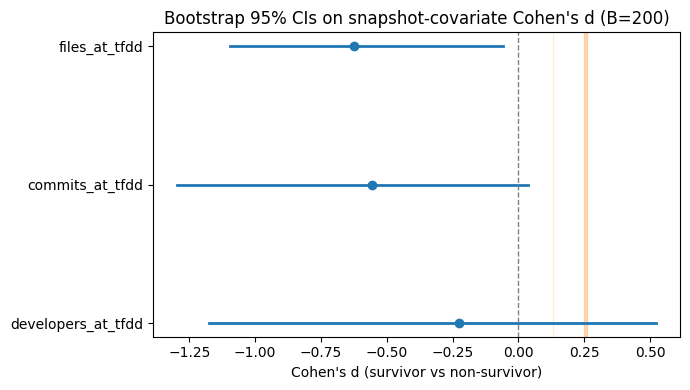

In [12]:
print("=" * 78)
print(f"Corpus: n_founder_only_tfdd={len(tfdd_repos)}  "
      f"survivors={sum(1 for r in tfdd_repos if r['binary_survival'] == 1)}  "
      f"non-survivors={sum(1 for r in tfdd_repos if r['binary_survival'] == 0)}")
print("=" * 78)

print("\n-- Step 1: covariate Cohen's d bootstrap CIs --")
print(f"{'covariate':22s} {'d':>8s} {'CI_lo':>8s} {'CI_hi':>8s}  {'flag':14s}  avelino_inside")
for row in step1["table"]:
    d = row["point_d"]
    lo = row["bootstrap_95ci_lo"]
    hi = row["bootstrap_95ci_hi"]
    d_s = f"{d:.3f}" if d is not None else "n/a"
    lo_s = f"{lo:.3f}" if lo is not None else "n/a"
    hi_s = f"{hi:.3f}" if hi is not None else "n/a"
    print(f"{row['covariate']:22s} {d_s:>8s} {lo_s:>8s} {hi_s:>8s}  {row['resolution_flag']:14s}  {row['avelino_ref_inside_ci']}")

print("\n-- Step 2: placebo percentile CI --")
print(f"status={step2['status']}  point_estimate={step2['reported_percentile_point_estimate']}th pctile  "
      f"n_null_draws={step2['reported_n_null_draws']} (target {step2['reported_target_n_null_draws']})")

print("\n-- Step 3: identity spot-check --")
print(f"n_sampled={step3['n_sampled']}  n_pass={step3['n_pass']}  n_alias_merge_error={step3['n_alias_merge_error']}  "
      f"n_ambiguous={step3['n_ambiguous']}")
print(f"observed_error_rate={step3['observed_error_rate']:.3f}  "
      f"wilson_95ci=[{step3['wilson_95ci_lo']:.3f}, {step3['wilson_95ci_hi']:.3f}]")

print("\n-- Step 4: success-criteria reclassification --")
for c in step4["criteria_reclassification"]:
    print(f"[{c['classification']:20s}] {c['criterion']}")

# -- plot: bootstrap CIs on Cohen's d vs the Avelino et al. reference range --
computable = [row for row in step1["table"] if row["point_d"] is not None]
fig, ax = plt.subplots(figsize=(7, 4))
ys = list(range(len(computable)))
for y, row in zip(ys, computable):
    lo, hi, d = row["bootstrap_95ci_lo"], row["bootstrap_95ci_hi"], row["point_d"]
    ax.plot([lo, hi], [y, y], color="tab:blue", lw=2)
    ax.plot(d, y, "o", color="tab:blue")
    ref = row["avelino_reference_value"]
    if ref is not None:
        ax.axvspan(ref[0], ref[1], color="tab:orange", alpha=0.15)
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_yticks(ys)
ax.set_yticklabels([row["covariate"] for row in computable])
ax.set_xlabel("Cohen's d (survivor vs non-survivor)")
ax.set_title(f"Bootstrap 95% CIs on snapshot-covariate Cohen's d (B={B_BOOTSTRAP})")
fig.tight_layout()
plt.show()